# Machine Learning Project - Password Strength Classifiers

Simone Piras 70/90/00539, Giovanni Presenti 70/90/00556, Alessia Tiddia 70/90/00501

#### Introduction 
This work aims to compare different classifiers for password strength prediction using a dataset of passwords with their respective strength labels.

#### Initial operations

In [2]:
import pandas as pd
import os

# Constants to define the number of training and testing samples
N_TRAIN = 10000
N_TEST = 100000


# Load the dataset
dirname = os.getcwd()
filename = os.path.join(dirname, "Dataset/data.csv")
data = pd.read_csv(filename, on_bad_lines="skip")
# N_TEST =  len(data) - N_TRAIN

#### Feature extraction

In [3]:
import numpy as np


# Shuffle the dataset
data_shuffled = data.sample(frac=1)

# Ensure the 'password' column is treated as string
data_shuffled["password"] = data_shuffled["password"].astype(str)

# Extract features
pass_length_train = data_shuffled["password"].str.len().head(N_TRAIN).values
digits_train = (data_shuffled["password"].head(N_TRAIN).apply(lambda x: len([c for c in x if c.isdigit()])).values)
symbols_train = (data_shuffled["password"].head(N_TRAIN).apply(lambda x: len([c for c in x if not c.isalnum()])).values)
upper_train = (data_shuffled["password"].head(N_TRAIN).apply(lambda x: len([c for c in x if c.isupper()])).values)
lower_train = (data_shuffled["password"].head(N_TRAIN).apply(lambda x: len([c for c in x if c.islower()])).values)
unique_chars_train = data_shuffled["password"].head(N_TRAIN).apply(lambda x: len(set(x))).values

pass_length_test = data_shuffled["password"].str.len().tail(N_TEST).values
digits_test = (data_shuffled["password"].tail(N_TEST).apply(lambda x: len([c for c in x if c.isdigit()])).values)
symbols_test = (data_shuffled["password"].tail(N_TEST).apply(lambda x: len([c for c in x if not c.isalnum()])).values)
upper_test = (data_shuffled["password"].tail(N_TEST).apply(lambda x: len([c for c in x if c.isupper()])).values)
lower_test = (data_shuffled["password"].tail(N_TEST).apply(lambda x: len([c for c in x if c.islower()])).values)
unique_chars_test = data_shuffled["password"].tail(N_TEST).apply(lambda x: len(set(x))).values

# Normalize features by password length (avoid division by zero)
digits_train_norm = digits_train / np.where(pass_length_train == 0, 1, pass_length_train)
symbols_train_norm = symbols_train / np.where(pass_length_train == 0, 1, pass_length_train)
upper_train_norm = upper_train / np.where(pass_length_train == 0, 1, pass_length_train)
lower_train_norm = lower_train / np.where(pass_length_train == 0, 1, pass_length_train)
unique_ratio_train = unique_chars_train / np.where(pass_length_train == 0, 1, pass_length_train)

digits_test_norm = digits_test / np.where(pass_length_test == 0, 1, pass_length_test)
symbols_test_norm = symbols_test / np.where(pass_length_test == 0, 1, pass_length_test)
upper_test_norm = upper_test /  np.where(pass_length_test == 0, 1, pass_length_test)
lower_test_norm = lower_test /  np.where(pass_length_test == 0, 1, pass_length_test)
unique_ratio_test = unique_chars_test / np.where(pass_length_test == 0, 1, pass_length_test)

ytr = data_shuffled["strength"].head(N_TRAIN).values
yts = data_shuffled["strength"].tail(N_TEST).values


#### Display Train and Test subsets by password strenght

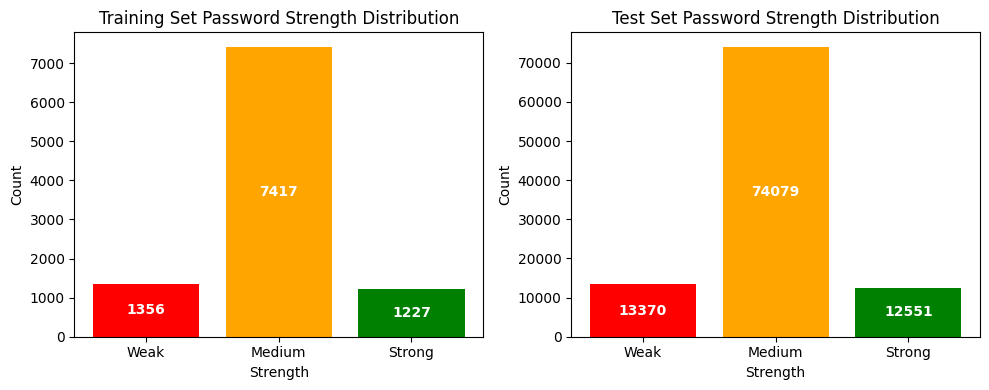

In [4]:
import matplotlib.pyplot as plt

# Display the distribution of password strength in the training and test sets
train_counts = pd.Series(ytr).value_counts().sort_index()
test_counts = pd.Series(yts).value_counts().sort_index()

strength_labels = ["Weak", "Medium", "Strong"]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
bars1 = plt.bar(strength_labels, train_counts, color=["red", "orange", "green"])
plt.title("Training Set Password Strength Distribution")
plt.xlabel("Strength")
plt.ylabel("Count")
# Add value labels inside the bars
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height / 2, f"{int(height)}", ha="center", va="center", color="white", fontweight="bold",)

plt.subplot(1, 2, 2)
bars2 = plt.bar(strength_labels, test_counts, color=["red", "orange", "green"])
plt.title("Test Set Password Strength Distribution")
plt.xlabel("Strength")
plt.ylabel("Count")
# Add value labels inside the bars
for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height / 2, f"{int(height)}", ha="center", va="center", color="white", fontweight="bold",)

plt.tight_layout()
plt.show()

#### Classifiers definition

In [5]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

# Define the classifiers with their parameters
KNN_clf = KNeighborsClassifier(n_neighbors=5)
SVM_clf = SVC(kernel="rbf")
DT_clf = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=0)
GNB_clf = GaussianNB()
SGD_reg = SGDClassifier(loss="hinge", penalty="l2")

# List of classifiers to be trained and tested
clfs = [KNN_clf, SVM_clf, DT_clf, GNB_clf, SGD_reg]

#### Test with password lenght, number of digits, number of symbols, number of uppercase, number of lowercase and number of unique characters 

In [15]:
import time

# Prepare the training and testing feature sets
xtr = np.array([pass_length_train, digits_train_norm, symbols_train_norm, upper_train_norm, lower_train_norm, unique_ratio_train]).T
xts = np.array([pass_length_test, digits_test_norm, symbols_test_norm, upper_test_norm, lower_test_norm, unique_ratio_test]).T

# Fit each classifier, make predictions, and evaluate performance
def train(xtr,ytr):
    for clf in clfs:

        print("\n")
        print(f"---\t\t{clf.__class__.__name__}\t\t---\n")
        tic = time.perf_counter()
        clf.fit(xtr, ytr)
        toc = time.perf_counter()
        print(f"\tTraining time:\t {toc-tic:.4f} seconds")

train(xtr, ytr)



---		KNeighborsClassifier		---

	Training time:	 0.0145 seconds


---		SVC		---

	Training time:	 0.1420 seconds


---		DecisionTreeClassifier		---

	Training time:	 0.0061 seconds


---		GaussianNB		---

	Training time:	 0.0026 seconds


---		SGDClassifier		---

	Training time:	 0.0796 seconds


#### Classifiers evaluation



---		KNeighborsClassifier		---

	Prediction time: 6.4903 seconds


              precision    recall  f1-score   support

        Weak      1.000     1.000     1.000     13370
      Medium      1.000     1.000     1.000     74079
      Strong      1.000     1.000     1.000     12551

    accuracy                          1.000    100000
   macro avg      1.000     1.000     1.000    100000
weighted avg      1.000     1.000     1.000    100000



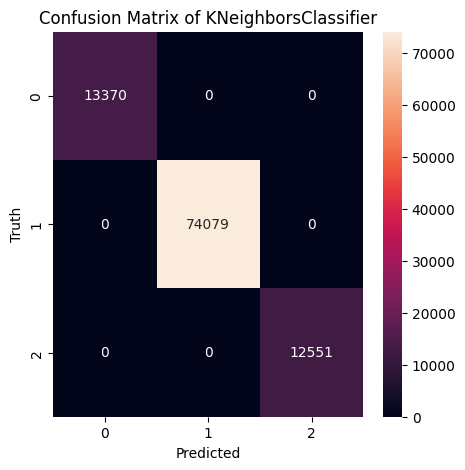



---		SVC		---

	Prediction time: 3.5236 seconds


              precision    recall  f1-score   support

        Weak      1.000     1.000     1.000     13370
      Medium      1.000     1.000     1.000     74079
      Strong      1.000     0.999     1.000     12551

    accuracy                          1.000    100000
   macro avg      1.000     1.000     1.000    100000
weighted avg      1.000     1.000     1.000    100000



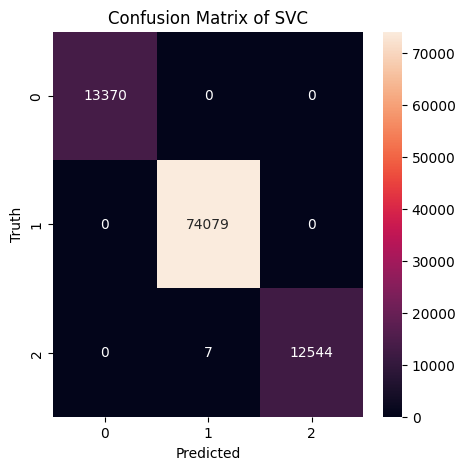



---		DecisionTreeClassifier		---

	Prediction time: 0.0070 seconds


              precision    recall  f1-score   support

        Weak      1.000     1.000     1.000     13370
      Medium      1.000     1.000     1.000     74079
      Strong      1.000     1.000     1.000     12551

    accuracy                          1.000    100000
   macro avg      1.000     1.000     1.000    100000
weighted avg      1.000     1.000     1.000    100000



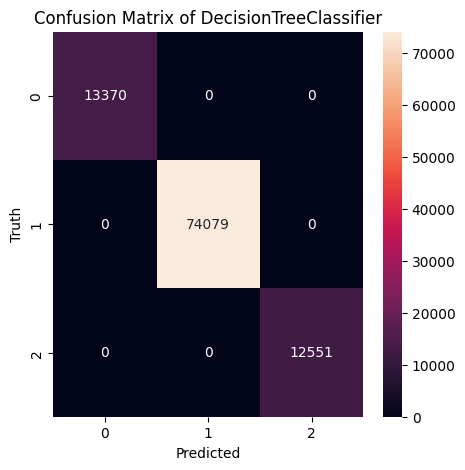



---		GaussianNB		---

	Prediction time: 0.0222 seconds


              precision    recall  f1-score   support

        Weak      1.000     0.918     0.957     13370
      Medium      0.986     0.985     0.985     74079
      Strong      0.900     0.981     0.939     12551

    accuracy                          0.976    100000
   macro avg      0.962     0.961     0.960    100000
weighted avg      0.977     0.976     0.976    100000



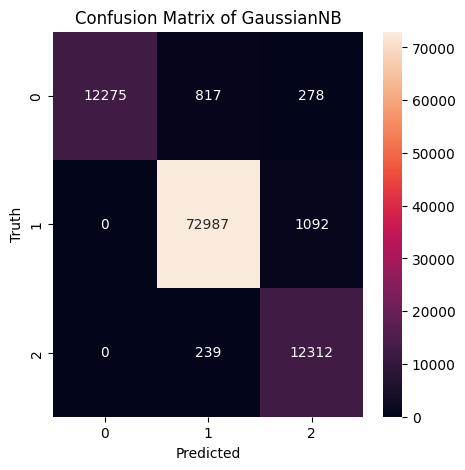



---		SGDClassifier		---

	Prediction time: 0.0075 seconds


              precision    recall  f1-score   support

        Weak      0.991     1.000     0.995     13370
      Medium      1.000     0.998     0.999     74079
      Strong      1.000     1.000     1.000     12551

    accuracy                          0.999    100000
   macro avg      0.997     0.999     0.998    100000
weighted avg      0.999     0.999     0.999    100000



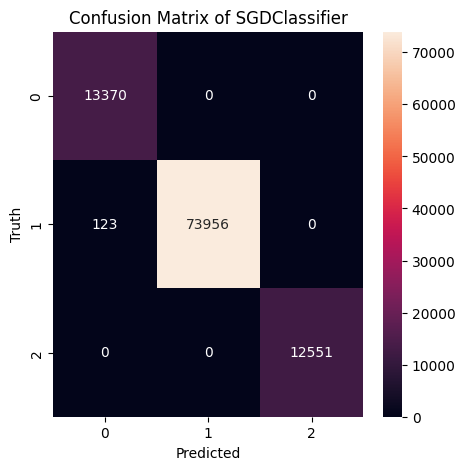

In [16]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


def plot_confusion_matrix(y_test, y_pred, classifier_name):
    """
    Plots the confusion matrix for a given set of true and predicted labels using a heatmap.

    Args:
        y_test (array-like): True labels of the test dataset.
        y_pred (array-like): Predicted labels from the classifier.
        classifier_name (str): Name of the classifier to display in the plot title.

    Returns:
        None: Displays the confusion matrix plot.
    """
    plt.figure(figsize=(5, 5))
    plt.title("Confusion Matrix of " + classifier_name)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.xlabel("Predicted")
    plt.ylabel("Truth")
    plt.show()


# Fit each classifier, make predictions, and evaluate performance
def test(xts, yts):
    for clf in clfs:
        print("\n")
        print(f"---\t\t{clf.__class__.__name__}\t\t---\n")
        tic = time.perf_counter()
        predictions = clf.predict(xts)
        toc = time.perf_counter()
        print(f"\tPrediction time: {toc-tic:.4f} seconds")
        print("\n")
        print(classification_report(yts, predictions, target_names=["Weak", "Medium", "Strong"], digits=3))
        plot_confusion_matrix(yts, predictions, clf.__class__.__name__)

test(xts, yts)

#### Features importance evaluation

Importances: [0.415 0.    0.    0.    0.    0.   ]


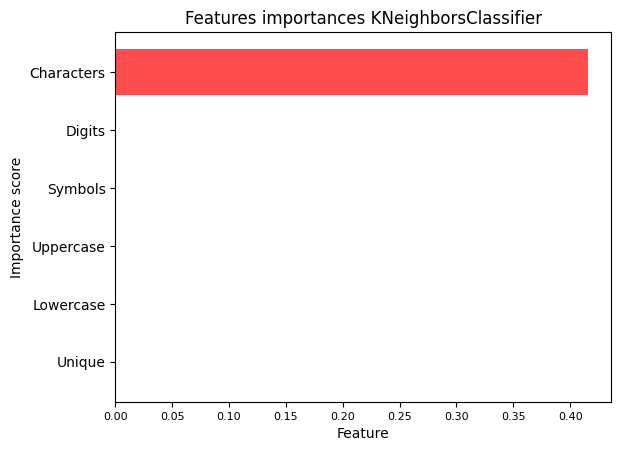

In [ ]:
from sklearn.inspection import permutation_importance

def feature_importance_histogram(importances, feature_names=None, title=None):
    """
    Plots a histogram of feature importances.
    Parameters
    ----------
    importances: list or array-like
        The importance scores for each feature.
    feature_names: list of str, optional
        Names of the features to use as x-axis labels.
    title : str, optional
        The title of the plot.
    """
    colors = ["purple", "cyan", "lightgreen", "yellow", "black", "red"]
    n_features = len(importances)
    if feature_names is None:
        feature_names = [f"Feature {i}" for i in range(n_features)]

    plt.barh(
        range(n_features),
        importances[::-1],
        tick_label=feature_names,
        color=colors[:n_features][::-1],
        linewidth=1.2,
        alpha=0.7,
    )
    plt.xlabel("Feature")
    plt.ylabel("Importance score")
    plt.title(title)
    plt.xticks(fontsize=8)
    plt.show()

# Calculate and plot feature importances for each classifier
def feature_importance(xts, yts):
    for clf in clfs:
        results = permutation_importance(clf, xts, yts, n_repeats=1, random_state=0)
        importances = results.importances_mean
        print("Importances:", np.round(importances, 3))
        if xts.shape[1] == 6:
            feature_names=["Characters", "Digits", "Symbols", "Uppercase", "Lowercase", "Unique"]
        elif xts.shape[1] == 5:
            feature_names=["Digits", "Symbols", "Uppercase", "Lowercase", "Unique"]
        feature_importance_histogram(importances, feature_names[::-1], title=f"Features importances {clf.__class__.__name__}")

feature_importance(xts, yts)

#### Tests with Digits, Symbols, Upper, Lower and Unique characters as Features.

In [9]:
# Split the dataset into features and target variable
xtr = np.array([digits_train_norm, symbols_train_norm, upper_train_norm, lower_train_norm, unique_chars_train]).T
xts = np.array([digits_test_norm, symbols_test_norm, upper_test_norm, lower_test_norm, unique_chars_test]).T

train(xtr, ytr)



---		KNeighborsClassifier		---

	Training time:	 0.0232 seconds


---		SVC		---

	Training time:	 1.5245 seconds


---		DecisionTreeClassifier		---

	Training time:	 0.0081 seconds


---		GaussianNB		---

	Training time:	 0.0036 seconds


---		SGDClassifier		---

	Training time:	 0.2014 seconds




---		KNeighborsClassifier		---

	Prediction time: 6.3267 seconds


              precision    recall  f1-score   support

        Weak      0.910     0.979     0.943     13370
      Medium      0.989     0.980     0.985     74079
      Strong      0.987     0.958     0.972     12551

    accuracy                          0.977    100000
   macro avg      0.962     0.972     0.967    100000
weighted avg      0.978     0.977     0.978    100000



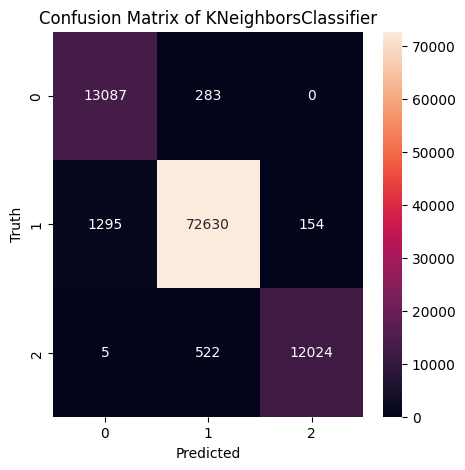



---		SVC		---

	Prediction time: 26.1584 seconds


              precision    recall  f1-score   support

        Weak      0.672     0.581     0.623     13370
      Medium      0.911     0.946     0.928     74079
      Strong      0.983     0.900     0.940     12551

    accuracy                          0.892    100000
   macro avg      0.855     0.809     0.830    100000
weighted avg      0.888     0.892     0.889    100000



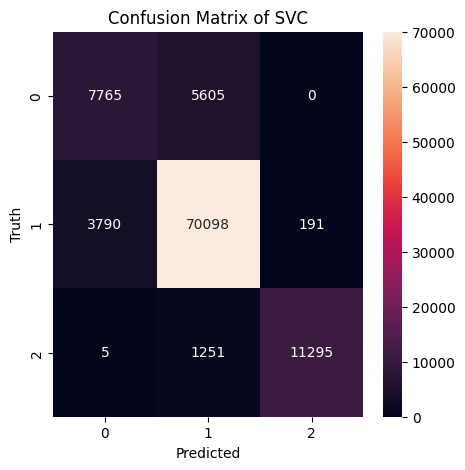



---		DecisionTreeClassifier		---

	Prediction time: 0.0072 seconds


              precision    recall  f1-score   support

        Weak      0.529     0.874     0.659     13370
      Medium      0.974     0.852     0.909     74079
      Strong      0.956     0.999     0.977     12551

    accuracy                          0.873    100000
   macro avg      0.820     0.909     0.848    100000
weighted avg      0.912     0.873     0.884    100000



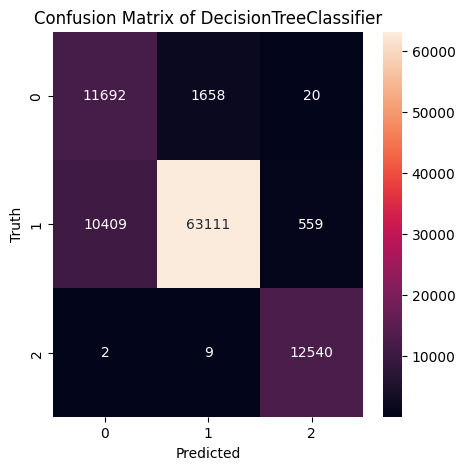



---		GaussianNB		---

	Prediction time: 0.0190 seconds


              precision    recall  f1-score   support

        Weak      0.634     0.394     0.486     13370
      Medium      0.888     0.943     0.915     74079
      Strong      0.881     0.917     0.898     12551

    accuracy                          0.866    100000
   macro avg      0.801     0.751     0.767    100000
weighted avg      0.853     0.866     0.855    100000



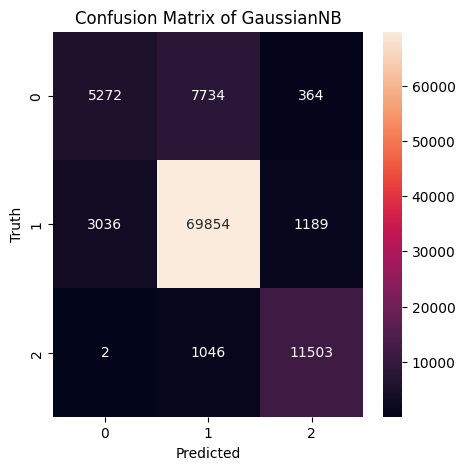



---		SGDClassifier		---

	Prediction time: 0.0058 seconds


              precision    recall  f1-score   support

        Weak      0.671     0.285     0.401     13370
      Medium      0.867     0.973     0.917     74079
      Strong      0.985     0.878     0.928     12551

    accuracy                          0.869    100000
   macro avg      0.841     0.712     0.749    100000
weighted avg      0.856     0.869     0.849    100000



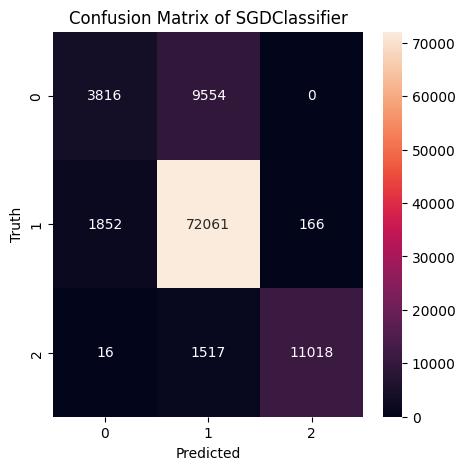

In [10]:
# Fit each classifier, make predictions, and evaluate performance
test(xts, yts)

Importances: [0.149 0.004 0.035 0.175 0.263]


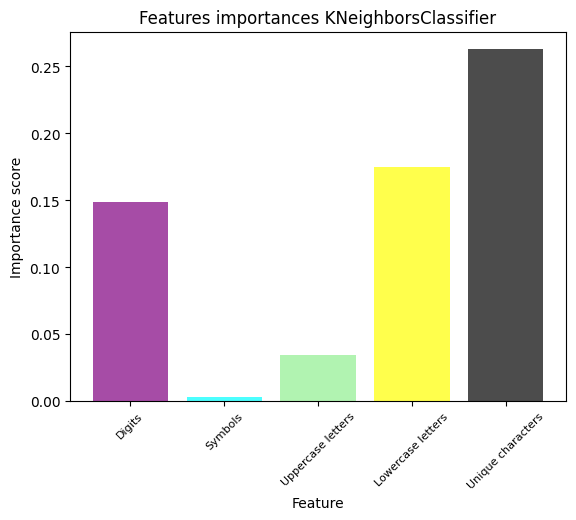

Importances: [0.011 0.    0.003 0.01  0.278]


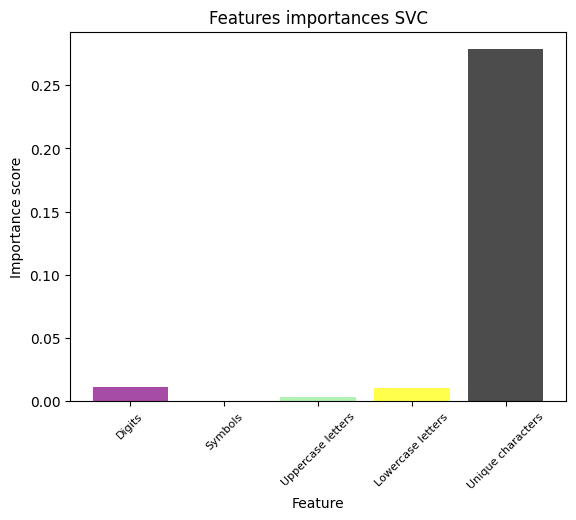

Importances: [0.    0.018 0.191 0.081 0.132]


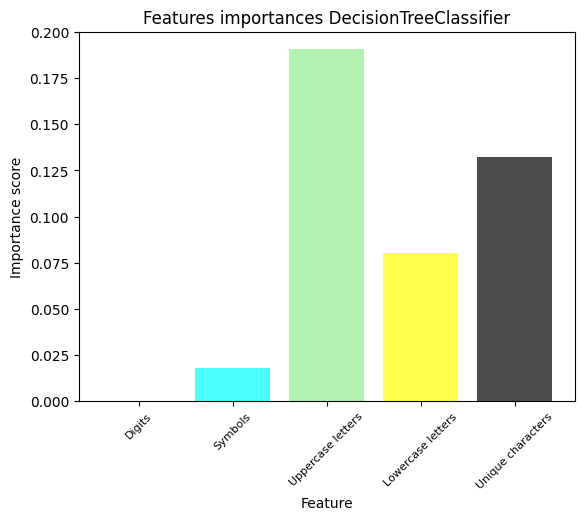

Importances: [-0.     0.01   0.074  0.002  0.149]


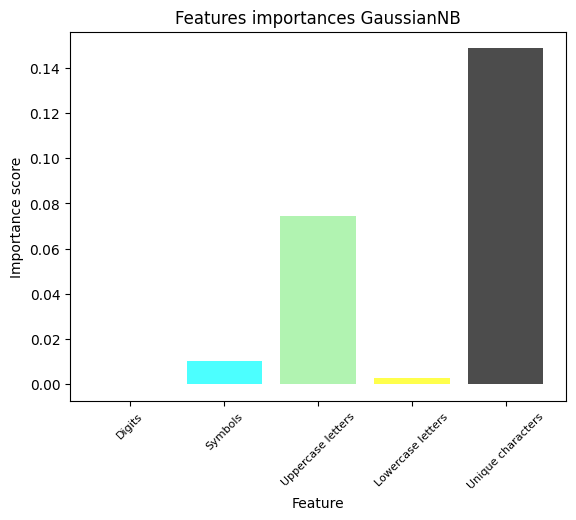

Importances: [0.086 0.    0.002 0.036 0.221]


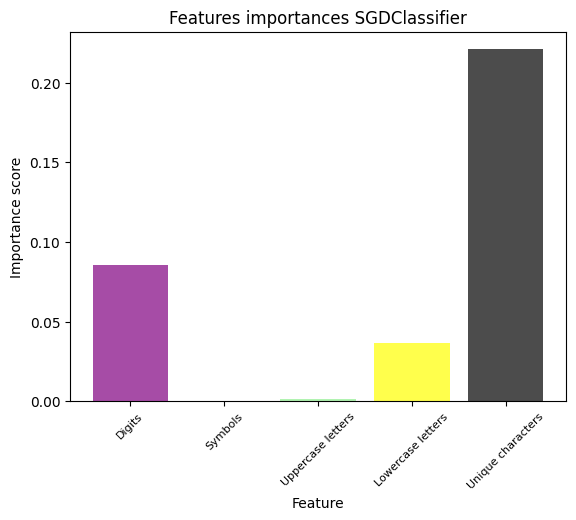

In [11]:
# Calculate and plot feature importances for each classifier
feature_importance(xts, yts)

#### Tests with only Password Length as a Feature.

In [12]:
# Split the dataset into features and target variable
xtr = np.array([pass_length_train]).T
xts = np.array([pass_length_test]).T

train(xtr, ytr)



---		KNeighborsClassifier		---

	Training time:	 0.0044 seconds


---		SVC		---

	Training time:	 0.0230 seconds


---		DecisionTreeClassifier		---

	Training time:	 0.0021 seconds


---		GaussianNB		---

	Training time:	 0.0013 seconds


---		SGDClassifier		---

	Training time:	 0.0798 seconds




---		KNeighborsClassifier		---

	Prediction time: 6.8407 seconds


              precision    recall  f1-score   support

        Weak      1.000     1.000     1.000     13370
      Medium      1.000     1.000     1.000     74079
      Strong      1.000     1.000     1.000     12551

    accuracy                          1.000    100000
   macro avg      1.000     1.000     1.000    100000
weighted avg      1.000     1.000     1.000    100000



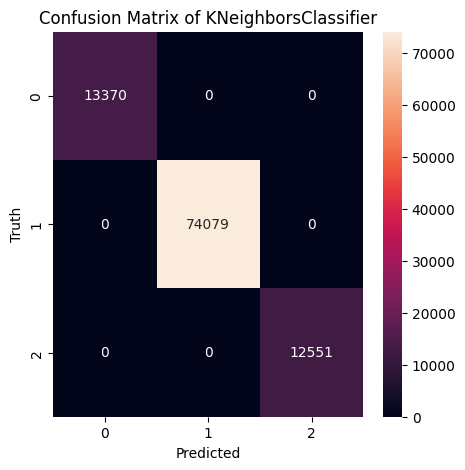



---		SVC		---

	Prediction time: 0.4106 seconds


              precision    recall  f1-score   support

        Weak      1.000     1.000     1.000     13370
      Medium      1.000     1.000     1.000     74079
      Strong      1.000     1.000     1.000     12551

    accuracy                          1.000    100000
   macro avg      1.000     1.000     1.000    100000
weighted avg      1.000     1.000     1.000    100000



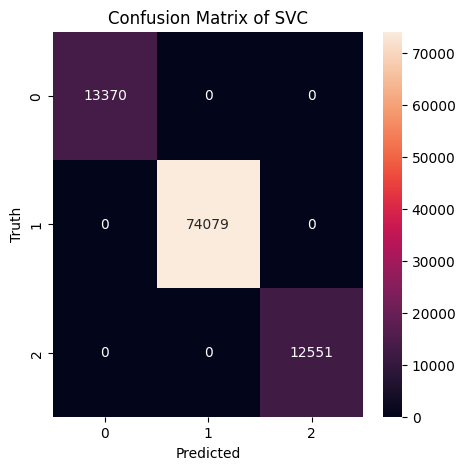



---		DecisionTreeClassifier		---

	Prediction time: 0.0051 seconds


              precision    recall  f1-score   support

        Weak      1.000     1.000     1.000     13370
      Medium      1.000     1.000     1.000     74079
      Strong      1.000     1.000     1.000     12551

    accuracy                          1.000    100000
   macro avg      1.000     1.000     1.000    100000
weighted avg      1.000     1.000     1.000    100000



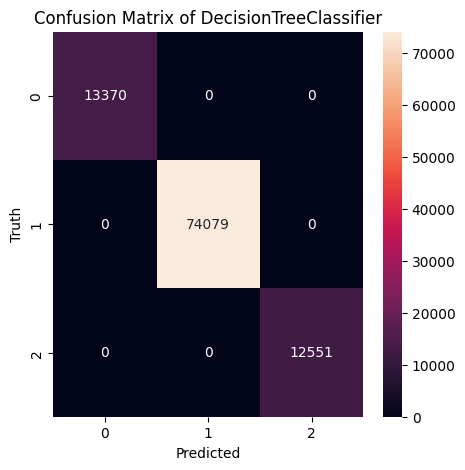



---		GaussianNB		---

	Prediction time: 0.0058 seconds


              precision    recall  f1-score   support

        Weak      1.000     0.999     1.000     13370
      Medium      1.000     1.000     1.000     74079
      Strong      1.000     1.000     1.000     12551

    accuracy                          1.000    100000
   macro avg      1.000     1.000     1.000    100000
weighted avg      1.000     1.000     1.000    100000



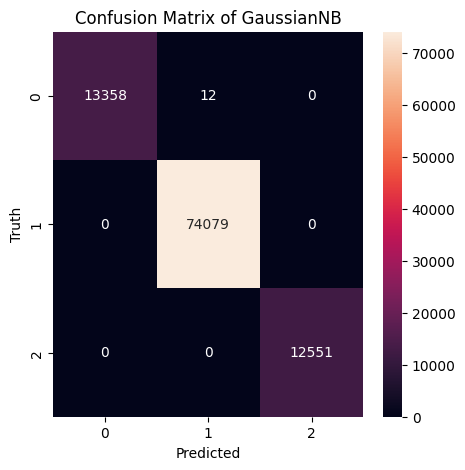



---		SGDClassifier		---

	Prediction time: 0.0054 seconds


              precision    recall  f1-score   support

        Weak      1.000     1.000     1.000     13370
      Medium      0.978     1.000     0.989     74079
      Strong      1.000     0.867     0.929     12551

    accuracy                          0.983    100000
   macro avg      0.993     0.956     0.973    100000
weighted avg      0.984     0.983     0.983    100000



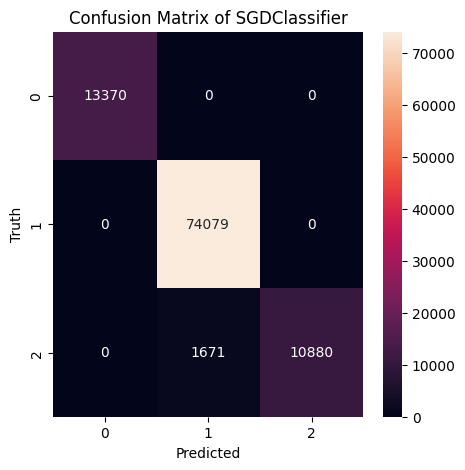

In [13]:
# Fit each classifier, make predictions, and evaluate performance
test(xts, yts)

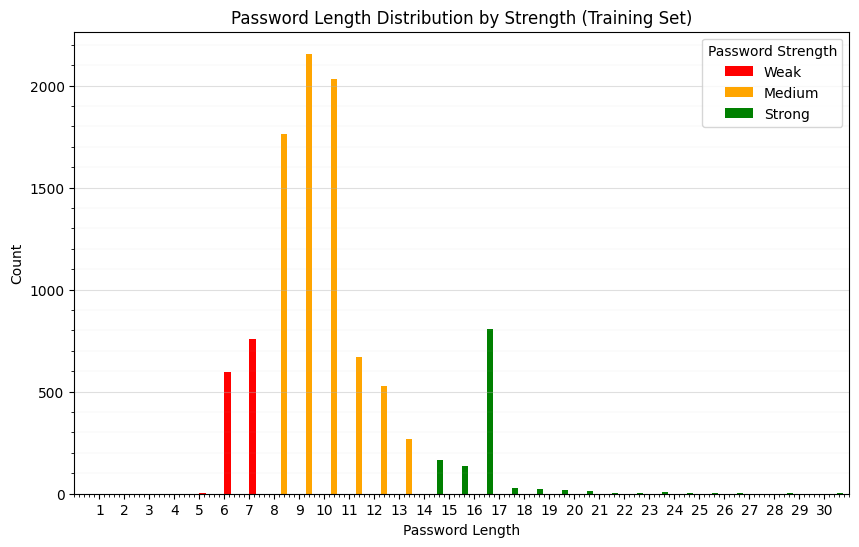

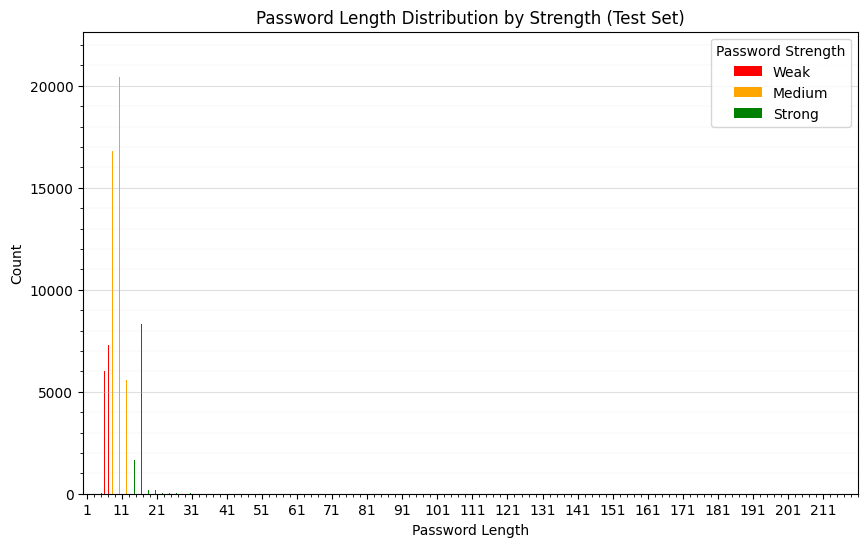

In [14]:
def plot_dataset(x, y, title):
    plt.figure(figsize=(10, 6))
    classes = np.unique(y) 
    colors = ["red", "orange", "green", "blue", "purple", "cyan", "magenta"]
    all_lengths = x[:, 0]
    min_len = int(all_lengths.min())
    max_len = int(all_lengths.max())
    bin_edges = np.arange(min_len, max_len + 2)  # one bin per length

    width = (bin_edges[1] - bin_edges[0]) / (len(classes) + 1)
    legend_names = ["Weak", "Medium", "Strong"]

    for i, k in enumerate(classes):
        lengths = x[y == k, 0]
        hist, _ = np.histogram(lengths, bins=bin_edges)
        plt.bar(
            bin_edges[:-1] + i * width,
            hist,
            width=width,
            color=colors[i % len(colors)],
            align="edge",
            label=legend_names[i],
        )

    plt.xlabel("Password Length")
    plt.ylabel("Count")
    plt.title(title)
    plt.legend(title="Password Strength")
    plt.grid(axis="y", alpha=0.4)
    plt.minorticks_on()
    plt.grid(which="minor", axis="y", alpha=0.2, linewidth=0.3)
    plt.xlim(min_len - 1, max_len + 1)
    plt.xticks(np.arange(min_len, max_len + 1, step=max(1, (max_len-min_len)//20)))
    plt.show()

# Plot the distributions of password lengths for training and test sets
plot_dataset(xtr, ytr, title="Password Length Distribution by Strength (Training Set)")
plot_dataset(xts, yts, title="Password Length Distribution by Strength (Test Set)")